##Zadatak 1 - Predviđanje cijena kuća u Bostonu


a) Učitati The Boston Housing Price skup podataka. Skup podataka je dio Keras biblioteke te se može učitati
sljedećim kodom:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import boston_housing
from keras.models import Sequential
from keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler
from keras.optimizers import Adam

(train_data, train_targets), (test_data, test_targets) = boston_housing.load_data()

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


b) Koji je oblik podataka za treniranje, a koji za testiranje? Koliko ima ukupno atributa (značajki)?

In [2]:
print("Oblik trening podataka:", train_data.shape)
print("Oblik test podataka:", test_data.shape)
print("Broj atributa:", train_data.shape[1])

Oblik trening podataka: (404, 13)
Oblik test podataka: (102, 13)
Broj atributa: 13


c) Koji je opseg vrijednosti (min i max ) za svaki atribut u skupu podataka? A koji je opseg vrijednosti za ciljne
(eng. target) vrijednosti?

In [3]:
#opseg za atribute
print("Min vrijednost atributa:", np.min(train_data, axis=0))
print("Max vrijednost atributa:", np.max(train_data, axis=0))

#Opseg za ciljane vrijednosti
print("Min vrijednost atributa:", np.min(train_targets))
print("Max vrijednost atributa:", np.max(train_targets))

Min vrijednost atributa: [6.3200e-03 0.0000e+00 4.6000e-01 0.0000e+00 3.8500e-01 3.5610e+00
 2.9000e+00 1.1296e+00 1.0000e+00 1.8800e+02 1.2600e+01 3.2000e-01
 1.7300e+00]
Max vrijednost atributa: [ 88.9762 100.      27.74     1.       0.871    8.725  100.      10.7103
  24.     711.      22.     396.9     37.97  ]
Min vrijednost atributa: 5.0
Max vrijednost atributa: 50.0


d) S obzirom da podaci zauzimaju široke spektre vrijednosti, izvršiti skaliranje korištenjem MinMaxScaler-a.
Obavezno povesti računa da se parametri scaler-a za skaliranje izračunaju nad trening skupom podataka, a
da se skaliranje izvrši i nad trening i nad test skupom;


In [4]:
scaler = MinMaxScaler()
train_data_scaled = scaler.fit_transform(train_data)
test_data_scaled = scaler.transform(test_data)

e) Napisati pomoćnu funkciju def model_mreze() koja će vraćati model mreže (return model) opisan u
nastavku. Model treba da ima 2 skrivena Dense sloja sa po 64 neurona sa relu aktivacijskim funkcijama.
Dimenzije ulaznog sloja odrediti na osnovu broja atributa skupa podataka. Treći, koji je i posljednji sloj, treba
imati samo jedan neuron i ne treba imati aktivacijsku funkciju;


In [5]:
def model_mreze():
    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(train_data.shape[1],)))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(1))  # Bez aktivacijske funkcije za regresiju
    return model

model = model_mreze()
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,121 (20.00 KB)

 Trainable params: 5,121 (20.00 KB)

 Non-trainable params: 0 (0.00 B)

f) Kompajlirati model da koristi mse funkciju gubitka, adam optimizator i mae metriku. S obzirom da su ciljne
vijednosti izražene u hiljadama dolara, metrika MAE govori koliko model griješi u hiljadama dolara. Na primjer,
ukoliko je vrijednost MAE = 4.2, to znači da predviđanja modela odstupaju u prosjeku za $4200;


In [6]:
model.compile(optimizer = 'adam', loss = 'mse', metrics = ['mae'])

g) Izvršiti treniranje modela na 100 epoha, sa veličinom batch-a jednakoj 1. Koristiti 10% trening skupa za
validaciju. Kolika je postignuta vrijednost funkcije gubitka na kraju treniranja, a kolika je vrijednost metrike MAE? Grafički prikazati;

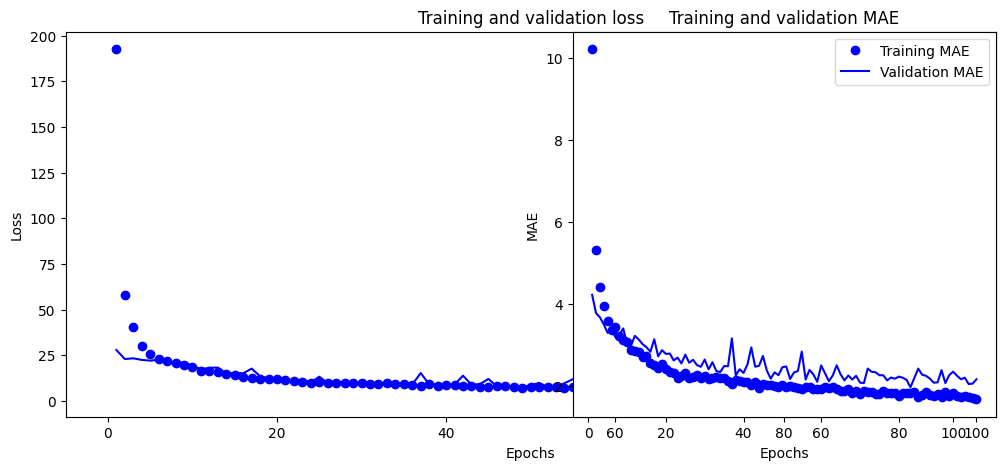

Final training loss: 5.5254, MAE: 1.6748
Final validation loss: 6.8743, MAE: 2.1610


In [7]:
history = model.fit(train_data_scaled, train_targets,
                    validation_split = 0.1,
                    epochs = 100,
                    batch_size = 1,
                    verbose = 0)

loss = history.history['loss']
val_loss = history.history['val_loss']
mae = history.history['mae']
val_mae = history.history['val_mae']

epochs = range(1, len(loss)+1)

plt.figure(figsize=(12,5))
plt.plot(1,2,1)
plt.plot(epochs, loss, 'bo', label = 'Training loss')
plt.plot(epochs, val_loss, 'b', label = 'Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, mae, 'bo', label='Training MAE')
plt.plot(epochs, val_mae, 'b', label='Validation MAE')
plt.title('Training and validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()

plt.show()

final_loss = loss[-1]
final_mae = mae[-1]
final_val_loss = val_loss[-1]
final_val_mae = val_mae[-1]

print(f"Final training loss: {final_loss:.4f}, MAE: {final_mae:.4f}")
print(f"Final validation loss: {final_val_loss:.4f}, MAE: {final_val_mae:.4f}")

h) U prethodnom grafičkom prikazu problem predstavlja skala i visoka varijansa nad validacijskim skupom podataka. Iz tog razloga je korisno prikazati usrednjene vrijednosti i zanemariti prvih 10 uzoraka radi visoke skale
u početnim epohama. Ovakav prikaz nad validacijskim skupom podataka se može postići sljedećim kodom:


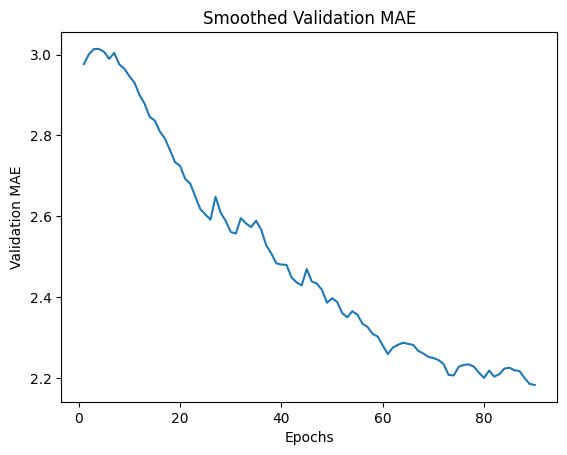

In [8]:
def smooth_curve(points, factor=0.9):
    smoothed_points = []
    for point in points:
        if smoothed_points:
            previous = smoothed_points[-1]
            smoothed_points.append(previous * factor + point * (1 - factor))
        else:
            smoothed_points.append(point)
    return smoothed_points

mae_history = history.history['val_mae']
smooth_mae_history = smooth_curve(mae_history[10:])

plt.plot(range(1, len(smooth_mae_history) + 1), smooth_mae_history)
plt.xlabel('Epochs')
plt.ylabel('Validation MAE')
plt.title('Smoothed Validation MAE')
plt.show()

i) Ponovo definisati model i istrenirati ga na 500 epoha. Ostale parametre ostaviti nepromijenjenim. Izvršiti
grafički prikaz usrednjenih vrijednosti kao u prethodnom zadatku. Uporediti ova dva grafička prikaza. Šta se
može zaključiti iz ovih grafika?

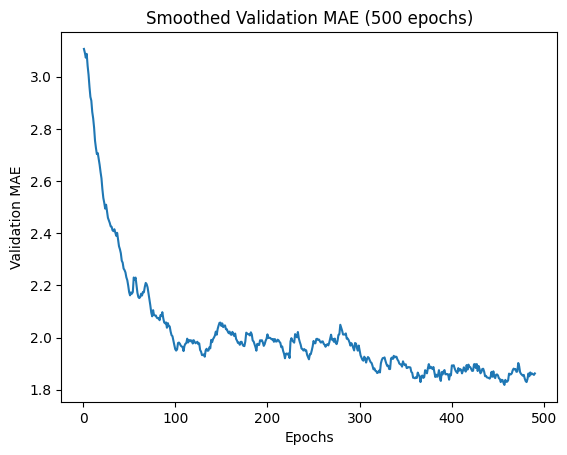

In [9]:
model = model_mreze()
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(train_data_scaled, train_targets,
                   validation_split=0.1,
                   epochs=500,
                   batch_size=1,
                   verbose=0)

# Prikaz usrednjenih vrijednosti
mae_history = history.history['val_mae']
smooth_mae_history = smooth_curve(mae_history[10:])

plt.plot(range(1, len(smooth_mae_history) + 1), smooth_mae_history)
plt.xlabel('Epochs')
plt.ylabel('Validation MAE')
plt.title('Smoothed Validation MAE (500 epochs)')
plt.show()

j) Izvršiti evaluaciju modela nad testnim skupom podataka. Koja je postignuta vrijednost funkcije gubitka, a
koja vrijednost metrike MAE? Koliko prosječno u dolarima griješi model u svojim predikcijama?


In [11]:
test_loss, test_mae = model.evaluate(test_data_scaled, test_targets, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Prosječna greška u dolarima: ${test_mae * 1000:.2f}")

Test loss: 12.9250
Test MAE: 2.3520
Prosječna greška u dolarima: $2351.97
